## Human In The Loop

In [41]:
from langchain_ollama import ChatOllama

MODEL_NAME1 = "qwen3:8b"
MODEL_NAME2 = "mistral:7b"
MODEL_NAME3 = "llama3.1:8b"
OLLAMA_URL = "http://127.0.0.1:11434"

llm = ChatOllama(
    model=MODEL_NAME3,
    base_url=OLLAMA_URL,
    temperature=0,
)

print(f"Connected to Ollama. Using local model: {MODEL_NAME1}")

Connected to Ollama. Using local model: qwen3:8b


In [42]:
response = llm.invoke("Reply with one short sentence confirming that local inference works.")
print(response.content)

Local inference is a valid method for making predictions or inferences about a specific subset of data.


In [43]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.types import Command, interrupt
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

In [44]:
from pathlib import Path
import os

from dotenv import load_dotenv

# Load the local .env before constructing Tavily, since the API key lives there.
env_candidates = [
    Path.cwd() / ".env",
    Path.cwd().parent / ".env",
    Path.cwd() / "Langgraph_tools" / "chatbot" / ".env",
]

for env_path in env_candidates:
    if env_path.exists():
        load_dotenv(env_path, override=True)
        break


tavily_key = os.getenv("TAVILY_API_KEY")
if not tavily_key:
    raise ValueError("TAVILY_API_KEY is missing. Add it to Langgraph_tools/chatbot/.env.")


class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)


@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human operator."""
    human_response = interrupt({"query": query})
    return human_response["data"]


search_tool = TavilySearch(api_key=tavily_key, max_results=2)
tools = [search_tool, human_assistance]
llm_with_tools = llm.bind_tools(tools)


def chatbot(state: State):
    message = llm_with_tools.invoke(state["messages"])
    return {"messages": [message]}


graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools_node", ToolNode(tools=tools))

graph_builder.add_edge(START, "chatbot")
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
    {
        "tools": "tools_node",
        END: END,
    },
)
graph_builder.add_edge("tools_node", "chatbot")

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)


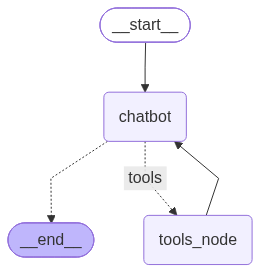

In [45]:
from IPython.display import display, Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Could not display graph image:", e)
    pass

In [46]:
user_input = "I need some expert assistance for building an AI agent. Could you request assistance for me?"
config = {"configurable": {"thread_id": "1"}}

events = graph.stream({"messages": user_input}, config=config, stream_mode="values")

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()


================================ Human Message =================================

I need some expert assistance for building an AI agent. Could you request assistance for me?


================================== Ai Message ==================================
Tool Calls:
  human_assistance (6b7368b7-bb79-4e7e-af09-56a12e1a0aec)
 Call ID: 6b7368b7-bb79-4e7e-af09-56a12e1a0aec
  Args:
    query: I need some expert assistance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (6b7368b7-bb79-4e7e-af09-56a12e1a0aec)
 Call ID: 6b7368b7-bb79-4e7e-af09-56a12e1a0aec
  Args:
    query: I need some expert assistance for building an AI agent. Could you request assistance for me?


In [48]:
human_response=("We, the experts are here to help! We would recommend you check out Langgraph to build your agent. "
                "It's much more reliable and extensible than simple autonomous agents. We can also provide you with a list of resources and tutorials to get started. "
                "Please let us know if you have any specific questions or areas you would like assistance with, and we will be happy to help!")

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config=config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (6b7368b7-bb79-4e7e-af09-56a12e1a0aec)
 Call ID: 6b7368b7-bb79-4e7e-af09-56a12e1a0aec
  Args:
    query: I need some expert assistance for building an AI agent. Could you request assistance for me?


NotImplementedError: Unsupported message type: <class 'langgraph.types.Command'>
For troubleshooting, visit: https://docs.langchain.com/oss/python/langchain/errors/MESSAGE_COERCION_FAILURE 